# 10 - EDA & PCA: Motor Repertoire Expansion

**Purpose:** Evaluate whether the intervention leads to measurable increase in behavioral complexity and spatial exploration. Compare T1 (Baseline), T2 (Peak Effect), and T3 (Afterglow/Recovery) using a **3-branch** approach:

- **Branch A (Dynamics):** `__zeroed_rel_...__omega_mag` — rotational speed and rhythmic complexity.
- **Branch B (Pose):** Quaternion components ($q_w, q_x, q_y, q_z$) per joint — body shapes and postures.
- **Branch C (Reach):** `__lin_rel_p[xyz]` (Hips at origin) — volumetric reach.

All processing logic lives in **EDA_PCA.py**; this notebook handles configuration, calls, and display (Verification Tables, Hero Figures, Interactive Deep Dive).

---

In [1]:
# ============================================================
# Phase 0: Configuration & Integrity Checks
# ============================================================
import os
import sys
from pathlib import Path

if os.path.basename(os.getcwd()) == "notebooks":
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
else:
    PROJECT_ROOT = os.path.abspath(os.getcwd())
SRC_PATH = os.path.join(PROJECT_ROOT, "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

import pandas as pd
from EDA_PCA import run_integrity_checks

# Subject 671, batch from JSON
SUBJECT_ID = "651_p2_r1"
BATCH_CONFIG_PATH = Path(PROJECT_ROOT) / "batch_configs" / f"subject_{SUBJECT_ID}_all.json"

result = run_integrity_checks(
    batch_config=str(BATCH_CONFIG_PATH),
    project_root=PROJECT_ROOT,
)

# Store available timepoints for downstream use (dynamic: works with 2 or 3 sessions)
AVAILABLE_TIMEPOINTS = result.get("available_timepoints", ["T1", "T2", "T3"])

# Numerical Verification Table
table_rows = result["table_rows"]
if table_rows:
    df_verify = pd.DataFrame(table_rows)
    df_verify.rename(columns={"n_omega": "ω cols", "n_q": "q cols", "n_xyz": "XYZ cols"}, inplace=True)
    # Add duration column: Frames / fs
    if "Frames" in df_verify.columns and "Median fs (Hz)" in df_verify.columns:
        df_verify["Duration (s)"] = (df_verify["Frames"] / df_verify["Median fs (Hz)"]).round(1)
    col_order = ["Session ID", "Frames", "Median fs (Hz)", "Duration (s)", "Max Gap (ms)", "ω cols", "q cols", "XYZ cols"]
    df_verify = df_verify[[c for c in col_order if c in df_verify.columns]]
    styled_v = (
        df_verify.style
        .set_caption("Phase 0: Data Integrity Summary")
        .format(precision=2, na_rep="—")
        .set_table_styles([
            {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px"), ("text-align", "left")]},
            {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-size", "11px")]},
            {"selector": "td", "props": [("font-size", "11px")]},
        ])
    )
    display(styled_v)
else:
    print("No table rows (missing parquet files or insufficient sessions).")

# Warnings (non-blocking — e.g. one timepoint missing)
for warn in result.get("warnings", []):
    print(f"  ⚠️  {warn}")

# Errors (blocking)
for err in result["errors"]:
    print(f"  ❌ {err}")

# Final status summary
n_sessions = len(AVAILABLE_TIMEPOINTS)
tp_label = " / ".join(AVAILABLE_TIMEPOINTS)
if result["passed"]:
    status_str = f"**PASS** — {n_sessions} session(s): {tp_label}"
else:
    status_str = f"**FAIL** — see errors above"
print(f"\n{'='*50}")
print(f"Phase 0 Status: {status_str}")
print(f"{'='*50}")

,Session ID,Frames,Median fs (Hz),Duration (s),Max Gap (ms),ω cols,q cols,XYZ cols
0,T1,19303,120.00,160.90,8.33,19,76,57
1,T2,21601,120.00,180.00,8.33,19,76,57
2,T3,22486,120.00,187.40,8.33,19,76,57



Phase 0 Status: **PASS** — 3 session(s): T1 / T2 / T3


## Pre-Processing: Time-Window Slicer

Standardize the analysis window for all sessions. Discard the first `TRIM_START_SEC` seconds (warm-up) and keep only `ANALYSIS_DURATION_SEC` seconds. This ensures T1, T2, T3 are compared over an identical time budget. Set `ENABLE_TRIMMING = False` to skip.

In [2]:
# ============================================================
# Pre-Processing: Time-Window Slicer
# ============================================================
# Standardize analysis window: discard warm-up, keep fixed duration.
# Toggle ENABLE_TRIMMING = False to use full sessions.
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
from EDA_PCA import load_batch_config, get_session_mapping

# --- Configuration ---
TRIM_START_SEC = 20        # Seconds to discard from the beginning (warm-up)
ANALYSIS_DURATION_SEC = 120 # Seconds to keep for analysis 
ENABLE_TRIMMING = True     # Master toggle

# --- Joint Filter for PCA ---
# Control which joints enter PCA for ALL branches (Dynamics, Pose, Reach).
# By default ALL joints are included (both lists are None).
# Set ONE of the two lists — not both:
#   INCLUDE_JOINTS = ["Hips", "Spine", ...]  -> only these joints enter PCA
#   EXCLUDE_JOINTS = ["LeftFoot", ...]        -> these joints are removed; rest kept
INCLUDE_JOINTS = None  # e.g. ["Hips","Spine","Spine1","Neck","Head","LeftShoulder","RightShoulder","LeftArm","RightArm","LeftForeArm","RightForeArm","LeftHand","RightHand"]
EXCLUDE_JOINTS = None # e.g. ["LeftUpLeg","RightUpLeg","LeftLeg","RightLeg","LeftFoot","RightFoot"]

# --- Resolve session mapping & load parquets ---
# SUBJECT_ID and PROJECT_ROOT are set in Phase 0 (Cell 1); no override here.
try:
    _ = SUBJECT_ID
except NameError:
    raise RuntimeError("Run Phase 0 first — SUBJECT_ID is not defined.")
try:
    _ = PROJECT_ROOT
except NameError:
    raise RuntimeError("Run Phase 0 first — PROJECT_ROOT is not defined.")

config = load_batch_config(subject_id=SUBJECT_ID, project_root=PROJECT_ROOT)
_session_mapping = get_session_mapping(config, PROJECT_ROOT)

# Canonical T1/T2/T3 order (same logic as _get_representative_sessions_with_parquets)
_by_tp = {}
for m in _session_mapping:
    if Path(m["parquet_path"]).exists():
        _by_tp.setdefault(m["timepoint"], []).append(m)
_representative = [_by_tp[tp][0] for tp in ("T1", "T2", "T3") if tp in _by_tp]

data_frames = {}
for m in _representative:
    data_frames[m["timepoint"]] = pd.read_parquet(m["parquet_path"])

# --- Original session sizes (before trimming) ---
print(f"Original sessions loaded (SUBJECT_ID={SUBJECT_ID}):")
print("-" * 55)
for m in _representative:
    tp = m["timepoint"]
    df = data_frames[tp]
    n = len(df)
    if "time_s" in df.columns and n > 1:
        t_vals = df["time_s"].values
        _dt = float(np.median(np.diff(t_vals)))
        _fs = 1.0 / _dt if _dt > 0 else 30.0
        duration = n / _fs
    else:
        _fs = 30.0
        duration = n / _fs
    print(f"  {tp}: {n:>6} frames  |  {duration:>6.1f}s  |  fs={_fs:.0f} Hz")
print("-" * 55)
print()

# --- Trim ---
trimmed_dfs = []  # list in canonical T1/T2/T3 order for prepare_3branch_data(preloaded_dfs=...)

if ENABLE_TRIMMING:
    print(f"Time-Window Slicer: trim first {TRIM_START_SEC}s, keep {ANALYSIS_DURATION_SEC}s")
    print("=" * 65)
    for m in _representative:
        tp = m["timepoint"]
        df = data_frames[tp]
        original_frames = len(df)

        # Determine sampling rate from time_s column (fallback to 30 Hz)
        if "time_s" in df.columns:
            dt = np.diff(df["time_s"].values)
            median_dt = float(np.median(dt)) if len(dt) > 0 else 0
            fs = 1.0 / median_dt if median_dt > 0 else 30.0
        else:
            fs = 30.0

        start_frame = int(TRIM_START_SEC * fs)
        end_frame = start_frame + int(ANALYSIS_DURATION_SEC * fs)

        # Safety check
        if start_frame >= original_frames:
            print(f"  WARNING [{tp}]: session has only {original_frames} frames "
                  f"({original_frames/fs:.1f}s) — shorter than trim start ({TRIM_START_SEC}s). "
                  "Using full session.")
            trimmed_dfs.append(df.reset_index(drop=True))
            continue

        if end_frame > original_frames:
            actual_end_sec = original_frames / fs
            print(f"  WARNING [{tp}]: session ends at {actual_end_sec:.1f}s, "
                  f"before requested {TRIM_START_SEC + ANALYSIS_DURATION_SEC:.1f}s. "
                  f"Slicing {TRIM_START_SEC}s to end.")
            end_frame = original_frames

        # Slice & reset index
        df_trimmed = df.iloc[start_frame:end_frame].reset_index(drop=True)
        data_frames[tp] = df_trimmed
        trimmed_dfs.append(df_trimmed)

        kept_start = TRIM_START_SEC
        kept_end = TRIM_START_SEC + len(df_trimmed) / fs
        print(f"  {tp}: {original_frames:>6} frames -> {len(df_trimmed):>6} frames  "
              f"(fs={fs:.0f} Hz, kept {kept_start:.1f}s - {kept_end:.1f}s)")

    print("=" * 65)
    print(f"Trimming complete. {len(trimmed_dfs)} sessions ready for Phase 1.")
else:
    print("Time-Window Slicer: DISABLED (ENABLE_TRIMMING = False). Using full sessions.")
    for m in _representative:
        trimmed_dfs.append(data_frames[m["timepoint"]])

Original sessions loaded (SUBJECT_ID=651_p2_r1):
-------------------------------------------------------
  T1:  19303 frames  |   160.9s  |  fs=120 Hz
  T2:  21601 frames  |   180.0s  |  fs=120 Hz
  T3:  22486 frames  |   187.4s  |  fs=120 Hz
-------------------------------------------------------

Time-Window Slicer: trim first 20s, keep 120s
  T1:  19303 frames ->  14400 frames  (fs=120 Hz, kept 20.0s - 140.0s)
  T2:  21601 frames ->  14400 frames  (fs=120 Hz, kept 20.0s - 140.0s)
  T3:  22486 frames ->  14400 frames  (fs=120 Hz, kept 20.0s - 140.0s)
Trimming complete. 3 sessions ready for Phase 1.


## Phase 1: Unified Loader & Longitudinal Scaling

Load parquets for available sessions (T1/T2/T3), fit one **StandardScaler per branch** on concatenated data, transform each session separately. Then verify scaling integrity (combined mean ≈ 0, std ≈ 1, no NaN).

In [3]:
# ============================================================
# Phase 1: Prepare 3-branch data & scaling integrity
# ============================================================
from EDA_PCA import (
    load_batch_config,
    get_session_mapping,
    prepare_3branch_data,
    check_scaling_integrity,
)

# SUBJECT_ID and PROJECT_ROOT are set in Phase 0 (Cell 1)
config = load_batch_config(subject_id=SUBJECT_ID, project_root=PROJECT_ROOT)
session_mapping = get_session_mapping(config, PROJECT_ROOT)

# Run-specific results directory: named after SUBJECT_ID for clarity
RUN_DIR_NAME = f"Subject_{SUBJECT_ID}"
results_dir = (Path(PROJECT_ROOT) / "results" / RUN_DIR_NAME).resolve()
results_dir.mkdir(parents=True, exist_ok=True)
print(f"Results directory: {results_dir}  (SUBJECT_ID={SUBJECT_ID})")

# Pass trimmed DataFrames if the Time-Window Slicer ran; otherwise load from disk
try:
    _preloaded = trimmed_dfs if trimmed_dfs else None
except NameError:
    _preloaded = None

# Joint filter: INCLUDE_JOINTS / EXCLUDE_JOINTS from the Slicer config cell (default: None = all joints)
try:
    _inc = INCLUDE_JOINTS
except NameError:
    _inc = None
try:
    _exc = EXCLUDE_JOINTS
except NameError:
    _exc = None

prepared = prepare_3branch_data(
    session_mapping,
    preloaded_dfs=_preloaded,
    include_joints=_inc,
    exclude_joints=_exc,
)
scaling_status = check_scaling_integrity(prepared)

# Scaling Summary Table: Branch | Total Frames (T1+T2+T3) | Feature Count | Scaling Status
branch_display = {
    "dynamics": "Dynamics (ω)",
    "pose": "Pose (q)",
    "reach": "Reach (XYZ)",
}
rows = []
for key in ("dynamics", "pose", "reach"):
    data = prepared[key]
    total_frames = sum(data["n_frames_per_session"])
    feature_count = len(data["columns"])
    rows.append({
        "Branch": branch_display[key],
        "Total Frames (T1+T2+T3)": total_frames,
        "Feature Count": feature_count,
        "Scaling Status": scaling_status.get(key, "FAIL"),
    })
df_scaling = pd.DataFrame(rows)
styled_sc = (
    df_scaling.style
    .set_caption("Phase 1: Scaling Integrity Check")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px"), ("text-align", "left")]},
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-size", "11px")]},
        {"selector": "td", "props": [("font-size", "11px")]},
    ])
)
display(styled_sc)

# Joint filter summary
_jf = prepared.get("joint_filter", {})
_joints_used = _jf.get("joints_used", [])
if _jf.get("include") or _jf.get("exclude"):
    _mode = "INCLUDE" if _jf.get("include") else "EXCLUDE"
    _filt = _jf.get("include") or _jf.get("exclude")
    print(f"\nJoint Filter ({_mode}): {_filt}")
    print(f"Joints entering PCA ({len(_joints_used)}): {_joints_used}")
else:
    print(f"\nJoint Filter: OFF (all {len(_joints_used)} joints included)")

# Per-session frame count & duration summary
import numpy as np
print(f"\nPer-session frame counts (SUBJECT_ID={SUBJECT_ID}):")
_ref_branch = prepared.get("dynamics") or prepared.get("pose") or prepared.get("reach")
if _ref_branch:
    for tp, n_frames in zip(_ref_branch["timepoints"], _ref_branch["n_frames_per_session"]):
        duration_s = n_frames / 120.0  # assume 120 Hz; adjust if fs differs
        print(f"  {tp}: {n_frames:>6} frames  ({duration_s:.1f}s)")
    _total = sum(_ref_branch["n_frames_per_session"])
    print(f"  Total: {_total} frames  ({_total / 120.0:.1f}s)")

Results directory: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p2_r1  (SUBJECT_ID=651_p2_r1)


,Branch,Total Frames (T1+T2+T3),Feature Count,Scaling Status
0,Dynamics (ω),43200,19,PASS
1,Pose (q),43200,76,PASS
2,Reach (XYZ),43200,54,PASS



Joint Filter: OFF (all 19 joints included)

Per-session frame counts (SUBJECT_ID=651_p2_r1):
  T1:  14400 frames  (120.0s)
  T2:  14400 frames  (120.0s)
  T3:  14400 frames  (120.0s)
  Total: 43200 frames  (360.0s)


In [4]:
# ============================================================
# DISABLED: Legacy Phase 0 for subject 671_p2_r1
# (This cell overwrites SUBJECT_ID and would break the pipeline.
#  Kept for reference only — do NOT run in a top-to-bottom execution.)
# ============================================================
# To run for a different subject, change SUBJECT_ID in Cell 1 above.

## Phase 2: 3-Branch PCA Engine

Fit a single PCA per branch on **combined** (T1+T2+T3) scaled data; project each session into 3D (PC1, PC2, PC3). Full variance spectrum is retained for the $N_{90}$ metric in Phase 3. PCA objects are stored for loadings in Phase 4.

In [5]:
# ============================================================
# Phase 2: Run 3-branch PCA & display Variance Table
# ============================================================
from EDA_PCA import run_3branch_pca

pca_results = run_3branch_pca(prepared)

# Variance Table: Branch | PC1 % | PC2 % | PC3 % | Cumulative 3-PC % | Total Features
branch_display = {"dynamics": "Dynamics (ω)", "pose": "Pose (q)", "reach": "Reach (XYZ)"}
rows = []
for key in ("dynamics", "pose", "reach"):
    res = pca_results.get(key)
    if not res:
        continue
    r = res["explained_variance_ratio_"]
    pc1 = 100 * r[0] if len(r) > 0 else 0
    pc2 = 100 * r[1] if len(r) > 1 else 0
    pc3 = 100 * r[2] if len(r) > 2 else 0
    cum3 = 100 * sum(r[:3])
    rows.append({
        "Branch": branch_display[key],
        "PC1 %": round(pc1, 2),
        "PC2 %": round(pc2, 2),
        "PC3 %": round(pc3, 2),
        "Cumulative 3-PC %": round(cum3, 2),
        "Total Features": res["n_features"],
    })
df_variance = pd.DataFrame(rows)
styled_var = (
    df_variance.style
    .set_caption("PCA Variance Summary (combined T1 + T2 + T3 fit)")
    .format(precision=2)
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px"), ("text-align", "left")]},
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-size", "11px")]},
        {"selector": "td", "props": [("font-size", "11px")]},
    ])
)
display(styled_var)

,Branch,PC1 %,PC2 %,PC3 %,Cumulative 3-PC %,Total Features
0,Dynamics (ω),18.79,12.88,10.27,41.93,19
1,Pose (q),12.78,11.80,10.06,34.63,76
2,Reach (XYZ),23.90,17.94,14.24,56.08,54


## Phase 3: Exploration Metrics (V3.1 Suite)

**Complexity Stats** (Table A):
- **$N_{90}$:** Components to reach 90 % cumulative variance (dimensionality).
- **Shannon Entropy $H$ (bits):** State-space exploration uniformity (2-D histogram, global bins).
- **Sample Entropy (SampEn):** Temporal regularity of the PC1 time series ($m=2$, $r=0.2 \sigma$).
- **Variance Inequality (Gini):** Shape of the variance curve (0 = democratic, 1 = concentrated).

**Spatial Stats** (Table B):
- **Convex Hull Volume:** Raw + 95 % radial-trim robust volume in PC1–PC2–PC3 space.
- **Centroid Displacement:** Euclidean shift of the session centroid from T1.

In [6]:
# ============================================================
# Phase 3: V3.1 Exploration Metrics — Complexity & Spatial
# ============================================================
from EDA_PCA import (
    calculate_n90,
    calculate_3d_hull_volume,
    calculate_robust_3d_hull_volume,
    calculate_state_space_entropy,
    calculate_sample_entropy,
    calculate_centroid_displacement,
    calculate_whole_system_stats,
    build_complexity_table,
    build_spatial_table,
)

# --- Compute all metrics ---
n90_results = calculate_n90(pca_results, prepared)
stats_results = calculate_whole_system_stats(pca_results, prepared)
volume_results = calculate_3d_hull_volume(pca_results)
robust_volume_results = calculate_robust_3d_hull_volume(pca_results, trim_pct=5.0)
entropy_results = calculate_state_space_entropy(pca_results, n_bins=25)
sampen_results = calculate_sample_entropy(pca_results, m=2, r_factor=0.2)
centroid_results = calculate_centroid_displacement(pca_results)

# --- Table A: Complexity Stats ---
print("Table A — Complexity Stats")
print("=" * 72)
df_complexity = build_complexity_table(
    n90_results, stats_results, entropy_results, sampen_results,
)
styled_a = (
    df_complexity.style
    .set_caption("Table A: Complexity Stats per Branch × Session")
    .format(precision=4, na_rep="—")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px"), ("text-align", "left")]},
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-size", "11px")]},
        {"selector": "td", "props": [("font-size", "11px")]},
    ])
)
display(styled_a)

print()

# --- Table B: Spatial Stats ---
print("Table B — Spatial Stats")
print("=" * 72)
df_spatial = build_spatial_table(
    volume_results, robust_volume_results, centroid_results,
)
styled_b = (
    df_spatial.style
    .set_caption("Table B: Spatial Stats per Branch × Session")
    .format(precision=4, na_rep="—")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px"), ("text-align", "left")]},
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-size", "11px")]},
        {"selector": "td", "props": [("font-size", "11px")]},
    ])
)
display(styled_b)

# --- Compact Pivot: N90 per Branch × Session ---
print()
print("N90 Trend (quick view)")
print("-" * 50)
branch_display = {"dynamics": "Dynamics (ω)", "pose": "Pose (q)", "reach": "Reach (XYZ)"}
rows_n90 = []
for key in ("dynamics", "pose", "reach"):
    r = n90_results.get(key)
    if not r:
        continue
    row = {"Branch": branch_display[key]}
    for tp, n in zip(r["timepoints"], r["n90_per_session"]):
        row[f"{tp} N90"] = n
    rows_n90.append(row)
df_n90 = pd.DataFrame(rows_n90)
styled_n90 = (
    df_n90.style
    .set_caption("N90 — Components to 90 % Variance")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px"), ("text-align", "left")]},
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-size", "11px")]},
        {"selector": "td", "props": [("font-size", "11px")]},
    ])
)
display(styled_n90)

# --- Compact Pivot: Convex Hull Volume per Branch × Session ---
print()
print("Convex Hull Volume Trend (quick view)")
print("-" * 50)
rows_vol = []
for key in ("dynamics", "pose", "reach"):
    r_raw = volume_results.get(key, {})
    r_rob = robust_volume_results.get(key, {})
    if not r_raw:
        continue
    row = {"Branch": branch_display[key]}
    for tp, v_raw, v_rob in zip(
        r_raw.get("timepoints", []),
        r_raw.get("volumes", []),
        r_rob.get("volumes", []),
    ):
        row[f"{tp} Raw"] = round(v_raw, 2)
        row[f"{tp} Robust (95%)"] = round(v_rob, 2)
    rows_vol.append(row)
df_vol = pd.DataFrame(rows_vol)
styled_vol = (
    df_vol.style
    .set_caption("Convex Hull Volume — Raw & 95 % Robust Trim")
    .format(precision=2, na_rep="—")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px"), ("text-align", "left")]},
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-size", "11px")]},
        {"selector": "td", "props": [("font-size", "11px")]},
    ])
)
display(styled_vol)

Table A — Complexity Stats


,Session,Branch,N90,Shannon Entropy (bits),Sample Entropy,Variance Inequality (Gini)
0,T1,Dynamics (ω),14,5.9000,0.8445,0.0925
1,T2,Dynamics (ω),14,7.0500,0.8393,0.0419
2,T3,Dynamics (ω),14,6.7500,0.7896,0.0639
3,T1,Pose (q),35,6.0900,0.3179,0.0733
4,T2,Pose (q),34,6.8400,0.2618,0.1041
5,T3,Pose (q),35,5.8800,0.3373,0.0941
6,T1,Reach (XYZ),11,6.6800,0.0614,0.0659
7,T2,Reach (XYZ),9,6.8500,0.0664,0.0196
8,T3,Reach (XYZ),9,6.3600,0.0695,0.0364



Table B — Spatial Stats


,Session,Branch,Convex Hull Volume,Hull Volume (95% robust),Centroid Displacement
0,T1,Dynamics (ω),254.9100,115.1300,0.0000
1,T2,Dynamics (ω),654.2800,233.7200,2.8216
2,T3,Dynamics (ω),403.5700,215.3400,2.7192
3,T1,Pose (q),265.3900,181.7000,0.0000
4,T2,Pose (q),604.3400,308.0300,6.6208
5,T3,Pose (q),387.6500,232.5200,7.0704
6,T1,Reach (XYZ),661.6200,490.4300,0.0000
7,T2,Reach (XYZ),1427.9100,617.1900,1.0587
8,T3,Reach (XYZ),1169.8000,547.8900,2.1873



N90 Trend (quick view)
--------------------------------------------------


,Branch,T1 N90,T2 N90,T3 N90
0,Dynamics (ω),14,14,14
1,Pose (q),35,34,35
2,Reach (XYZ),11,9,9



Convex Hull Volume Trend (quick view)
--------------------------------------------------


,Branch,T1 Raw,T1 Robust (95%),T2 Raw,T2 Robust (95%),T3 Raw,T3 Robust (95%)
0,Dynamics (ω),254.91,115.13,654.28,233.72,403.57,215.34
1,Pose (q),265.39,181.70,604.34,308.03,387.65,232.52
2,Reach (XYZ),661.62,490.43,1427.91,617.19,1169.80,547.89


## Hero Figure 1: "The Complexity Triptych"

Three-row figure (Dynamics, Pose, Reach) showing cumulative explained variance curves for T1 / T2 / T3 on shared axes.  N90 markers on the 90 % threshold; Variance Inequality (Gini) in each legend.  If curves overlap perfectly, the intervention had no effect on that branch — this is the objective null-finding test.

findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica,

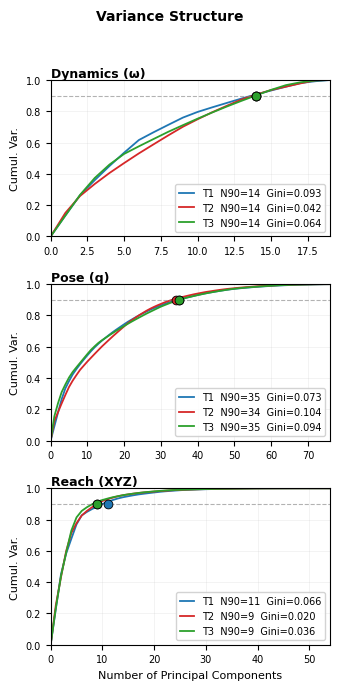

Saved: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p2_r1\Hero1_Complexity_Triptych.png


In [7]:
# ============================================================
# Hero Figure 1: "The Complexity Triptych" (single 3-row figure)
# ============================================================
from EDA_PCA import plot_complexity_triptych
import matplotlib.pyplot as plt

try:
    results_dir
except NameError:
    results_dir = (Path(PROJECT_ROOT) / "results" / f"Subject_{SUBJECT_ID}").resolve()
results_dir.mkdir(parents=True, exist_ok=True)

save_path = results_dir / "Hero1_Complexity_Triptych.png"
fig_triptych = plot_complexity_triptych(
    pca_results, prepared, stats_results,
    save_path=save_path, dpi=300,
)
plt.show(fig_triptych)
plt.close(fig_triptych)
print(f"Saved: {save_path}")

## Hero Figure 2: "The Density Shift"

3 rows (Dynamics, Pose, Reach) x 3 columns (T1, T2, T3).  Each cell: 2-D Kernel Density Estimate (PC1 vs PC2).  Global axis limits and colorbar per row guarantee that visual density is directly comparable.  Each cell annotates **Shannon Entropy** ($H$, bits) and **Sample Entropy** ($SampEn$).

c:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\src\EDA_PCA.py:1756: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0, 0.97, 0.97])
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
findfont: Font family 'Arial, Helvetica, sans-serif' not found.
fin

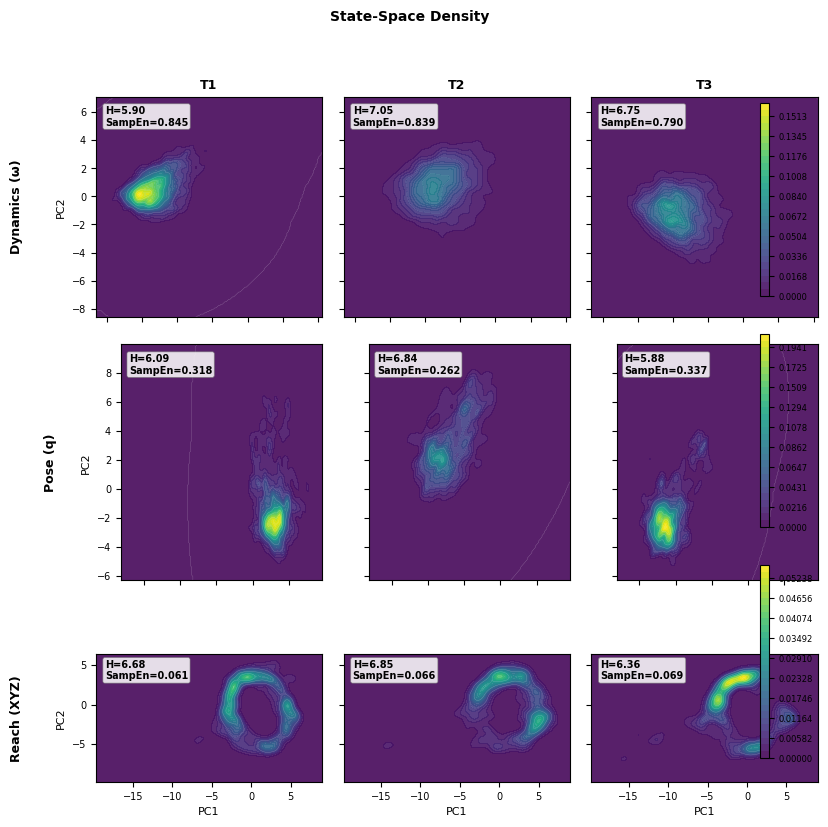

Saved: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p2_r1\Hero2_Density_Shift.png


In [8]:
# ============================================================
# Hero Figure 2: "The Density Shift" (3×3 KDE grid)
# ============================================================
from EDA_PCA import plot_density_shift_matrix
import matplotlib.pyplot as plt

save_path = results_dir / "Hero2_Density_Shift.png"
fig_density = plot_density_shift_matrix(
    pca_results,
    entropy_results=entropy_results,
    sampen_results=sampen_results,
    save_path=save_path, dpi=300,
)
plt.show(fig_density)
plt.close(fig_density)
print(f"Saved: {save_path}")

## Hero Figure 3: "The Spatial Envelope"

Three viewpoints (Front, Top, Isometric) of the 3-D convex hull overlay for the **Reach** branch.  T1 and T3 are rendered as wireframe; T2 as a semi-transparent surface.  5 % radial outlier trim is applied before hull computation.  If `kaleido` is installed, a static 3-panel PNG is saved; otherwise an interactive Plotly figure is returned.

In [9]:
# ============================================================
# Hero Figure 3: "The Spatial Envelope" (3-viewpoint hull overlay)
# ============================================================
from EDA_PCA import plot_static_spatial_envelope
import matplotlib
import matplotlib.pyplot as plt

# Attempt static export (kaleido); falls back to interactive Plotly
save_path_hull = results_dir / "Hero3_Spatial_Envelope.png"
fig_envelope = plot_static_spatial_envelope(
    pca_results,
    branch_key="reach",
    volume_results=volume_results,
    robust_volume_results=robust_volume_results,
    trim_pct=5.0,
    save_path=save_path_hull, dpi=300,
)
# If matplotlib figure (kaleido available), show & close; else show Plotly
if isinstance(fig_envelope, matplotlib.figure.Figure):
    plt.show(fig_envelope)
    plt.close(fig_envelope)
    print(f"Saved static: {save_path_hull}")
else:
    fig_envelope.show()
    print("kaleido not installed — showing interactive Plotly figure.")

C:\Users\drorh\AppData\Local\Temp\ipykernel_19656\2510472601.py:10: UserWarning: kaleido not installed — returning interactive Plotly figure instead of static 3-viewpoint panel. Install kaleido for publication-grade export: pip install kaleido
  fig_envelope = plot_static_spatial_envelope(


kaleido not installed — showing interactive Plotly figure.


## Phase 4: Anatomical Loadings (The "Who" of the Movement)

Identify the **Top 5 joints** contributing to variance in each branch: Anatomical Contribution Index = sum of squared loadings for PC1, PC2, PC3 per feature, aggregated by joint, normalized to 100%. Use this to check whether complexity is driven by axial (Spine/Neck) or peripheral (Hands/Feet) joints.

In [10]:
# ============================================================
# Phase 4: Joint loadings — Top 5 contributors per branch
# ============================================================
from EDA_PCA import calculate_joint_loadings

loadings_results = calculate_joint_loadings(pca_results)

branch_display = {"dynamics": "Dynamics (ω)", "pose": "Pose (q)", "reach": "Reach (XYZ)"}

# Top 5 Joint Contributors Table: Branch | Top 1 Joint (%) | Top 2 Joint (%) | ... | Top 5 Joint (%)
rows = []
for key in ("dynamics", "pose", "reach"):
    r = loadings_results.get(key)
    if not r:
        continue
    joints = r["top5_joints"]
    pcts = r["top5_pct"]
    row = {"Branch": branch_display[key]}
    for i in range(5):
        label = f"Top {i+1} Joint (%)"
        if i < len(joints):
            row[label] = f"{joints[i]} ({pcts[i]}%)"
        else:
            row[label] = ""
    rows.append(row)
df_loadings = pd.DataFrame(rows)
styled_ld = (
    df_loadings.style
    .set_caption("Phase 4: Top 5 Joint Contributors (Combined PCA Loadings)")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px"), ("text-align", "left")]},
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-size", "11px")]},
        {"selector": "td", "props": [("font-size", "11px")]},
    ])
)
display(styled_ld)

,Branch,Top 1 Joint (%),Top 2 Joint (%),Top 3 Joint (%),Top 4 Joint (%),Top 5 Joint (%)
0,Dynamics (ω),Neck (8.76%),Head (8.03%),LeftArm (6.04%),RightArm (5.8%),RightLeg (5.79%)
1,Pose (q),RightShoulder (7.39%),RightArm (6.77%),LeftShoulder (6.73%),LeftUpLeg (6.57%),LeftHand (6.57%)
2,Reach (XYZ),RightArm (6.51%),LeftArm (6.36%),RightForeArm (6.35%),LeftForeArm (6.28%),LeftHand (5.98%)


In [11]:
# ============================================================
# Phase 4 (upgrade): Session-specific loadings — Longitudinal Joint Shift Table
# ============================================================
from EDA_PCA import calculate_session_joint_loadings, longitudinal_joint_shift_table

session_loadings = calculate_session_joint_loadings(pca_results, prepared)
shift_rows = longitudinal_joint_shift_table(session_loadings, top_n=10)

df_shift = pd.DataFrame(shift_rows)
# Map branch key to display name
branch_display = {"dynamics": "Dynamics (ω)", "pose": "Pose (q)", "reach": "Reach (XYZ)"}
if "Branch" in df_shift.columns:
    df_shift["Branch"] = df_shift["Branch"].map(lambda k: branch_display.get(k, k))
# Dynamic column order: Branch | Joint | {tp} % ... | Change (...)
# (column names are now set dynamically by longitudinal_joint_shift_table based on available timepoints)
_fixed = ["Branch", "Joint"]
_dynamic = [c for c in df_shift.columns if c not in _fixed]
df_shift = df_shift[_fixed + _dynamic]
styled_sh = (
    df_shift.style
    .set_caption("Longitudinal Joint Shift (Top 10 movers per branch)")
    .format(precision=2, na_rep="—")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px"), ("text-align", "left")]},
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-size", "11px")]},
        {"selector": "td", "props": [("font-size", "11px")]},
    ])
)
display(styled_sh)

,Branch,Joint,T1 %,T2 %,T3 %,Change (T2-T1)
0,Dynamics (ω),Spine,7.48,4.96,5.01,-2.53
1,Dynamics (ω),Neck,6.74,4.26,6.43,-2.48
2,Dynamics (ω),Head,6.21,4.33,5.50,-1.87
3,Dynamics (ω),RightFoot,4.32,5.80,4.71,1.48
4,Dynamics (ω),RightShoulder,4.42,5.45,5.63,1.03
5,Dynamics (ω),LeftShoulder,4.46,5.41,5.59,0.95
6,Dynamics (ω),LeftFoot,4.41,5.35,5.17,0.93
7,Dynamics (ω),RightArm,4.08,4.93,5.73,0.85
8,Dynamics (ω),LeftHand,4.83,5.60,5.90,0.77
9,Dynamics (ω),LeftArm,4.26,5.01,5.59,0.75


### Whole-System Statistics & Longitudinal Strategy Table

Per-branch indices using the full joint set: variance is reconstructed from the global PCA (Y = X·V), attributed to features via squared loadings scaled by session PC variance, then aggregated by joint.  **Variance Inequality (Gini)** — concentration of variance across joints.  **Shannon Entropy** — joint-diversity (nats).  **Axial-Peripheral Ratio** — core vs. limbs drive.

In [12]:
# ============================================================
# Longitudinal Strategy Table & Index Legend
# ============================================================
from EDA_PCA import (
    calculate_whole_system_stats,
    longitudinal_strategy_table,
    get_index_definitions,
)

# stats_results was computed in Phase 3 cell; recompute only if missing
try:
    stats_results
except NameError:
    stats_results = calculate_whole_system_stats(pca_results, prepared)
strategy_rows = longitudinal_strategy_table(stats_results)

df_strategy = pd.DataFrame(strategy_rows)
branch_display = {"dynamics": "Dynamics (ω)", "pose": "Pose (q)", "reach": "Reach (XYZ)"}
if "Branch" in df_strategy.columns:
    df_strategy["Branch"] = df_strategy["Branch"].map(lambda k: branch_display.get(k, k))

# Remove "Sparseness" rows — metric was deprecated in V3.1
if "Metric" in df_strategy.columns:
    df_strategy = df_strategy[df_strategy["Metric"] != "Sparseness"].reset_index(drop=True)

# Rename metrics for clarity
_metric_rename = {"Gini": "Variance Inequality (Gini)", "Shannon": "Shannon Entropy (nats)"}
if "Metric" in df_strategy.columns:
    df_strategy["Metric"] = df_strategy["Metric"].map(lambda m: _metric_rename.get(m, m))

# Dynamic column order: Branch | Metric | {tp1} | {tp2} | ... | % Change (...)
_fixed = ["Branch", "Metric"]
_dynamic = [c for c in df_strategy.columns if c not in _fixed]
df_strategy = df_strategy[_fixed + _dynamic]

styled_strat = (
    df_strategy.style
    .set_caption("Longitudinal Strategy: Whole-System Indices per Branch")
    .format(precision=4, na_rep="—")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px"), ("text-align", "left")]},
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-size", "11px")]},
        {"selector": "td", "props": [("font-size", "11px")]},
    ])
)
display(styled_strat)

# Index Legend (PCA-logic explanations)
print("\n" + "=" * 60 + "\nIndex Legend\n" + "=" * 60)
for name, definition in get_index_definitions().items():
    print(f"\n• {name}\n  {definition}")

,Branch,Metric,T1,T2,T3,% Change (T1 vs T2)
0,Dynamics (ω),Variance Inequality (Gini),0.0925,0.0419,0.0639,-54.6900
1,Dynamics (ω),Shannon Entropy (nats),2.9308,2.9412,2.9381,0.3500
2,Dynamics (ω),AxialPeripheral,1.0560,0.7439,0.8269,-29.5500
3,Pose (q),Variance Inequality (Gini),0.0733,0.1041,0.0941,42.0500
4,Pose (q),Shannon Entropy (nats),2.9361,2.9276,2.9298,-0.2900
5,Pose (q),AxialPeripheral,0.9363,0.9542,0.9949,1.9100
6,Reach (XYZ),Variance Inequality (Gini),0.0659,0.0196,0.0364,-70.2100
7,Reach (XYZ),Shannon Entropy (nats),2.8834,2.8896,2.8883,0.2100
8,Reach (XYZ),AxialPeripheral,0.5500,0.6417,0.7038,16.6700



Index Legend

• Variance Inequality (Gini)
  Gini coefficient of the per-joint variance distribution reconstructed from the full PCA weight matrix.  Values near 0 indicate equal variance across joints (democratic); values near 1 indicate concentration in a few dominant joints.  Complements N90 by characterising the *shape* of the variance curve, not just the 90 % threshold.

• Shannon Entropy — State Space (bits)
  Entropy of a 2-D histogram (PC1 × PC2) with global bin edges (shared across all sessions).  Measures how *uniformly* the subject explores the principal-component plane.  Higher values indicate broader, less repetitive exploration; lower values indicate clustering in a few movement hotspots.

• Shannon Entropy — Joint Diversity (nats)
  Entropy of the per-joint variance proportions (discrete distribution over joints).  Measures whether all joints contribute equally to variance (high) or a few joints dominate (low).

• Sample Entropy (SampEn)
  Temporal regularity of the PC1 

In [13]:
# ============================================================
# Numerical Results Archive — Phase 0 to 5 Table Export
# ============================================================
from pathlib import Path
from EDA_PCA import save_numerical_tables_html

# Compile all statistical tables with clear titles (use globals() to avoid NameError if a cell was skipped)
_g = globals()
tables = [
    ("Phase 0: Numerical Verification Table", _g.get("df_verify")),
    ("Phase 1: Scaling Summary Table", _g.get("df_scaling")),
    ("Phase 2: Variance Table", _g.get("df_variance")),
    ("Phase 3 — Table A: Complexity Stats", _g.get("df_complexity")),
    ("Phase 3 — Table B: Spatial Stats", _g.get("df_spatial")),
    ("Phase 4: Joint Loadings (Top 5 per branch)", _g.get("df_loadings")),
    ("Phase 4: Session Loadings (Longitudinal)", _g.get("df_shift")),
    ("Phase 5: Longitudinal Strategy Table", _g.get("df_strategy")),
]
tables = [(t, d) for t, d in tables if d is not None]

# Save to run-specific results directory (results_dir set in Phase 1)
out_path = results_dir / f"Subject_{SUBJECT_ID}_Numerical_Tables.html"
n_saved, size_bytes = save_numerical_tables_html(
    tables, out_path, subject_id=str(SUBJECT_ID),
    available_timepoints=AVAILABLE_TIMEPOINTS,
)

print(f"Numerical archive saved: {n_saved} tables, {size_bytes:,} bytes ({size_bytes/1024:.1f} KB)")
print(f"Path: {out_path}")

Numerical archive saved: 8 tables, 15,858 bytes (15.5 KB)
Path: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p2_r1\Subject_651_p2_r1_Numerical_Tables.html


## Full EDA/PCA Report (Self-Contained HTML)

Export a **single self-contained HTML file** with every table, every hero figure (embedded as base64 PNG), trend plots, and interactive Plotly deep-dive — fully portable, no external image references.

In [14]:
# ============================================================
# Full EDA/PCA Report — single self-contained HTML
# ============================================================
from pathlib import Path
from EDA_PCA import save_full_eda_report_html

try:
    results_dir
except NameError:
    results_dir = (Path(PROJECT_ROOT) / "results" / f"Subject_{SUBJECT_ID}").resolve()
results_dir.mkdir(parents=True, exist_ok=True)

# ---- 1. Collect all tables ----
_g = globals()
report_tables = [
    ("Phase 0: Data Integrity Summary", _g.get("df_verify")),
    ("Phase 1: Scaling Summary", _g.get("df_scaling")),
    ("Phase 2: PCA Variance Summary", _g.get("df_variance")),
    ("Phase 3 — Table A: Complexity Stats", _g.get("df_complexity")),
    ("Phase 3 — Table B: Spatial Stats", _g.get("df_spatial")),
    ("Phase 4: Joint Loadings (Top 5 per Branch)", _g.get("df_loadings")),
    ("Phase 4: Session Loadings (Longitudinal Shift)", _g.get("df_shift")),
    ("Phase 5: Longitudinal Strategy Table", _g.get("df_strategy")),
]
report_tables = [(t, d) for t, d in report_tables if d is not None]

# ---- 2. Collect all static figures (PNGs saved by earlier cells) ----
hero_images = [
    ("Hero Figure 1: Complexity Triptych", results_dir / "Hero1_Complexity_Triptych.png"),
    ("Hero Figure 2: Density Shift Matrix", results_dir / "Hero2_Density_Shift.png"),
    ("Hero Figure 3: Spatial Envelope", results_dir / "Hero3_Spatial_Envelope.png"),
]
# Add trend plots if they exist
for trend_name in ["Volume", "Entropy", "Gini", "AxialPeripheral"]:
    p = results_dir / f"Trend_{trend_name}.png"
    if p.exists():
        hero_images.append((f"Index Trend: {trend_name}", p))

# Filter to only existing files (images that were actually saved)
report_images = [(t, str(p)) for t, p in hero_images if Path(p).exists()]

# ---- 3. Collect interactive Plotly figures (Phase 6 deep-dive) ----
report_plotly = []
try:
    for label, _short, fig_obj in branch_figures:
        report_plotly.append((f"Interactive Deep-Dive: {label}", fig_obj))
except NameError:
    pass  # Phase 6 cell was not run

# ---- 4. Generate the report ----
report_path = results_dir / f"Subject_{SUBJECT_ID}_Full_EDA_Report.html"
file_size = save_full_eda_report_html(
    output_path=report_path,
    subject_id=str(SUBJECT_ID),
    tables=report_tables,
    image_paths=report_images,
    plotly_figures=report_plotly,
    available_timepoints=AVAILABLE_TIMEPOINTS,
)

print(f"Full EDA/PCA report saved ({file_size / 1024:.1f} KB)")
print(f"Tables: {len(report_tables)}  |  Figures: {len(report_images)}  |  Interactive: {len(report_plotly)}")
print(f"Path: {report_path}")

Full EDA/PCA report saved (9172.3 KB)
Tables: 8  |  Figures: 3  |  Interactive: 0
Path: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p2_r1\Subject_651_p2_r1_Full_EDA_Report.html


## Phase 5: Legacy Dashboard (Disabled)

The legacy 4×3 dashboard is superseded by the Hero Figures above.  This cell is kept for reference but disabled.

In [15]:
# ============================================================
# Phase 5: Dashboard Visualization — COMMENTED OUT (no dual-axis 4x3 dashboard)
# ============================================================
# from pathlib import Path
# from EDA_PCA import create_results_dashboard, save_clean_dashboard_html, get_index_definitions
#
# try:
#     PROJECT_ROOT
# except NameError:
#     import os
#     PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(os.getcwd())
#
# out_path = results_dir / f"Subject_{SUBJECT_ID}_Clean_Analysis.html"
# fig = create_results_dashboard(
#     pca_results=pca_results,
#     n90_results=n90_results,
#     volume_results=volume_results,
#     stats_results=stats_results,
#     session_loadings=session_loadings,
#     output_path=None,
# )
# fig.update_layout(barmode="group")
# save_clean_dashboard_html(fig, out_path, subject_id="671", available_timepoints=AVAILABLE_TIMEPOINTS)
# fig.show()
# print(f"Saved clean report: {out_path}")
# print("\n" + "=" * 60 + "\nIndex Legend\n" + "=" * 60)
# for name, definition in get_index_definitions().items():
#     print(f"\n  {name}\n  {definition}")

## Standalone Index Trend Plots

Five high-resolution line/point plots (Volume, Shannon Entropy, Gini, Sparseness, Axial–Peripheral Ratio) to visualize longitudinal shifts in behavioral strategy. Dynamics (blue), Pose (orange), Reach (green). Saved as `Trend_*.png` in `results/`; HTML report with one chapter per index (plot + explanation) is generated below.

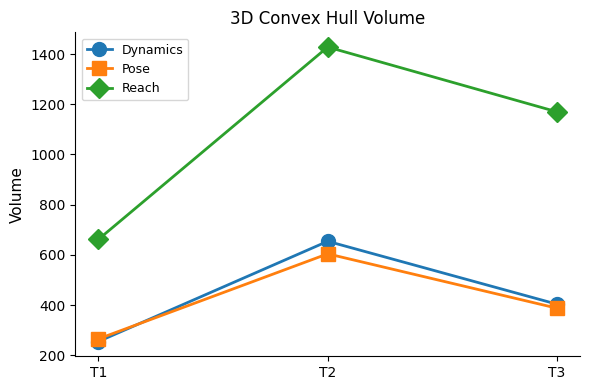

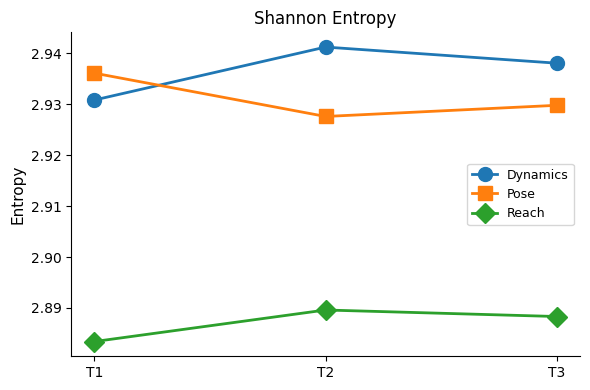

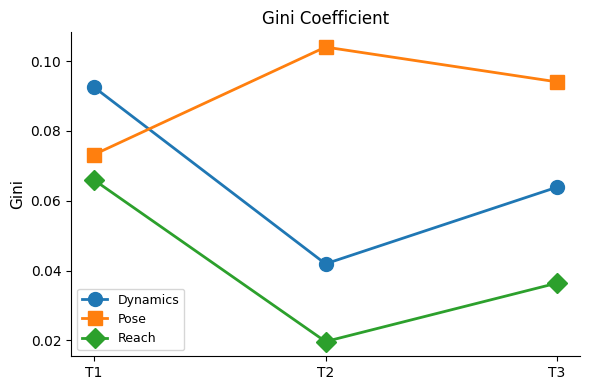

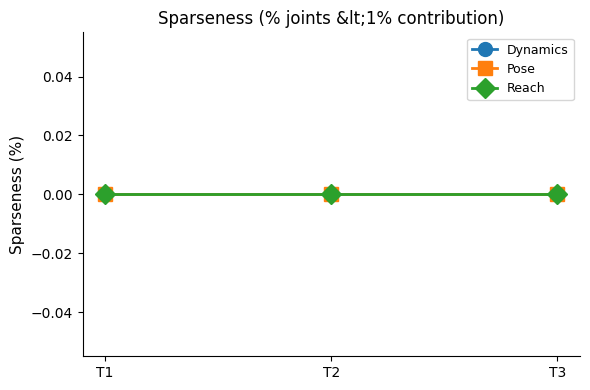

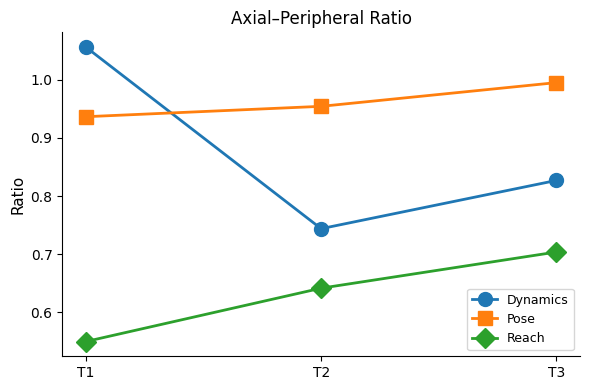

Index trend PNGs and HTML report saved in: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p2_r1
HTML: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p2_r1\Subject_651_p2_r1_Index_Trends.html


In [16]:
# ============================================================
# Index Trend Plots: generate, save PNGs, display vertically, then save HTML report
# ============================================================
from pathlib import Path
from EDA_PCA import plot_index_trends, save_index_trends_report_html
import matplotlib.pyplot as plt

# Ensure run-specific results dir exists (set in Phase 1; fallback if cell run alone)
try:
    results_dir
except NameError:
    results_dir = (Path(PROJECT_ROOT) / "results" / f"Subject_{SUBJECT_ID}").resolve()
results_dir.mkdir(parents=True, exist_ok=True)

trend_figures = plot_index_trends(
    stats_results, volume_results, n90_results,
    save_dir=results_dir,
    dpi=300,
)

# Display each plot vertically in the notebook
for name, fig in trend_figures:
    plt.show(fig)
    plt.close(fig)

# Save HTML report: five chapters (one per index), each with plot + explanation
index_trends_html = results_dir / f"Subject_{SUBJECT_ID}_Index_Trends.html"
save_index_trends_report_html(
    index_trends_html, results_dir, subject_id=str(SUBJECT_ID),
    available_timepoints=AVAILABLE_TIMEPOINTS,
)
print(f"Index trend PNGs and HTML report saved in: {results_dir}")
print(f"HTML: {index_trends_html}")

## Phase 6: Museum-Grade Sectional Report (Interactive Deep Dive)

One viewport-height section per branch. Each section: **Hero 3D** (left 60%), **Logic panel** (right 40%: N90, Volume, Gini/Entropy), **Anatomy footer** (joint loadings). Bootstrap container max-width 1200px, Key Findings legend at top. Saved as **Subject_671_Interactive_DeepDive.html**.

In [17]:
# ============================================================
# Phase 6: Sectional figures + Interactive Deep Dive HTML
# ============================================================
from pathlib import Path
from EDA_PCA import create_phase6_branch_figures, save_interactive_deepdive_html

try:
    results_dir
except NameError:
    results_dir = (Path(PROJECT_ROOT) / "results" / f"Subject_{SUBJECT_ID}").resolve()
results_dir.mkdir(parents=True, exist_ok=True)

branch_figures = create_phase6_branch_figures(
    pca_results, n90_results, volume_results, stats_results, session_loadings,
)
deepdive_path = results_dir / f"Subject_{SUBJECT_ID}_Interactive_DeepDive.html"
save_interactive_deepdive_html(
    branch_figures, deepdive_path, subject_id=str(SUBJECT_ID),
    available_timepoints=AVAILABLE_TIMEPOINTS,
)
print(f"Phase 6 report saved: {deepdive_path}")
# Optional: display first branch figure in notebook
branch_figures[0][2].show()

Phase 6 report saved: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p2_r1\Subject_651_p2_r1_Interactive_DeepDive.html
